# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# define a surgery function if required
# don't run this unless you know what you're doing

def surgery(config):
    config["model_type"] = "LegacyRegression"

In [5]:
from accelerate import Accelerator
from utilities import try_loading_model

# set up the model
config = {"modelname": "smallandshort-21", "PATH": ".."}

# try loading model and config
model, config = try_loading_model(config, surgery_func=surgery)

accelerator = Accelerator()

model = accelerator.prepare(model)

/Users/midataur/Documents/github/braids/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded config from file, config may be different.
Did some surgery


W0201 11:56:00.786160 56421 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [27]:
model

LegacyRegression(
  (token_embedding_table): Embedding(9, 402)
  (position_embedding): Embedding(10, 402)
  (embed_hook): Identity()
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=402, out_features=67, bias=False)
            (query): Linear(in_features=402, out_features=67, bias=False)
            (value): Linear(in_features=402, out_features=67, bias=False)
            (dropout): Dropout(p=0, inplace=False)
            (attention_hook): Identity()
            (sanity_hook): Identity()
          )
        )
        (proj): Linear(in_features=402, out_features=402, bias=True)
        (dropout): Dropout(p=0, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=402, out_features=1608, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1608, out_features=402, bias=True)
          (3): Dropout(p=0, i

In [30]:
import numpy as np

lmao = model.lm_head.weight.cpu().detach().numpy()

px.imshow(lmao @ np.transpose(lmao))

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('KCHwQXw6nL+6CSU/3NQ5v7ysHcC98r' ... 'K+vpxgx77i5pE9ZoLIwJj2AcG7eq5B'),
                    'dtype': 'f4',
                    'shape': '6, 6'}}],
    'layout': {'coloraxis': {'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']]},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.express as px

X = model.position_embedding.weight.cpu().detach().numpy()
pca = PCA(n_components=3)
pca.fit(X)

y = pca.transform(X)

px.scatter_3d(x=y[:,0],y=y[:,1],z=y[:,2], color="")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<br>z=%{z}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'scene': 'scene',
              'showlegend': False,
              'type': 'scatter3d',
              'x': {'bdata': 'BGxXwTIB6sB5Xrc+F5VZQKVrjEANaxpAyhjLPxxxqr1NTd2/RRcnQQ==', 'dtype': 'f4'},
              'y': {'bdata': 'jl3hQLQH3r6A7pTAPMDUwEa5mcAPYUfAppGZv5S9Nb6A/s284D1gQQ==', 'dtype': 'f4'},
              'z': {'bdata': 'MpCWP6oG98CpZf7AihaHwKj2dT+0XJZACz2lQClXwUBrcK1AlYJkwA==', 'dtype': 'f4'}}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'scene': {'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
                         'xaxis': {'title': {'text': 'x'}},
                         'yaxis': {'title': {'text': 'y'}},
                         'zaxis': {'title': {'text': 'z'}}},
               'template': '...'}
})

In [41]:
y.shape

(10, 2)

# Embedding pictures

In [26]:
import plotly.express as px
import numpy as np
import torch

embedding = model.position_embedding.weight.cpu().detach().numpy()

similarity = []

for x in embedding:
    row = []
    for y in embedding:
        row.append(np.dot(x, y)/(np.linalg.norm(x)*np.linalg.norm(y)))
    similarity.append(row)

similarity = np.array(similarity)

figure = px.imshow(
    similarity,
    title=f"{config['modelname']} state embedding similarity matrix"
)

hide_ui = True

if hide_ui:
    figure.update_layout(coloraxis_showscale=True)
    figure.update_xaxes(showticklabels=False)
    figure.update_yaxes(showticklabels=False)
    figure.update_layout(
        title="",
        autosize=False,
        margin=dict(
            l=0,
            r=0,
            b=0,
            t=0,
            pad=0
        )
    )

figure

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AQCAP9lEUT5fit68ksHuvT02tL0qhv' ... 'yj4SG9AUvkOhFfr7z5rbi7AACAPw=='),
                    'dtype': 'f4',
                    'shape': '10, 10'}}],
    'layout': {'autosize': False,
               'coloraxis': {'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']],
                             'showscale': True},
               'margin': {'b': 0, 'l': 0, 'pad': 0, 'r': 0, 't': 0},
               'template': '...',
               'title': {'text': ''},
               'xaxis': {'anchor': 'y',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'scaleanchor': 'y',
                         'showticklabels': False},
               'yaxis': {'anchor': 'x',
                         'autorange': 'reversed',
                         'constrain': 'domain',
                         'domain': [0.0, 1.0],
                         'showticklabels': False}}
})

In [7]:
config

{'modelname': 'smallandshort-21',
 'model_type': 'LegacyRegression',
 'dataset': 'smallandshort',
 'dataset_type': 'basicregression',
 'random_seed': 42,
 'braid_count': 4,
 'max_word_length': 10,
 'n_embed': 402,
 'n_heads': 6,
 'dropout': 0,
 'n_blocks': 8,
 'learning_rate': 0.00030000000000000003,
 'batchsize': 512,
 'weight_decay': 0.001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'threshold': 0.01,
 'n_workers': 0,
 'PATH': '..',
 'dataset_size': 4000000}

# True scratchpad

In [11]:
import torch

a = torch.tensor([1,2,3])

torch.exp(torch.abs(a))*a

tensor([ 2.7183, 14.7781, 60.2566])

# Messing around with knots

In [2]:
import GridPythonModule as gp

In [4]:
gp.available_knots()

3 crossings:
 3_1 

4 crossings:
 4_1 

5 crossings:

5_1  5_2  

6 crossings:

6_1  6_2  6_3  

7 crossings:

7_1  7_2  7_3  7_4  7_5  7_6  7_7  

8 crossings:

8_1  8_2  8_3  8_4  8_5  8_6  8_7  8_8  8_9  8_10  8_11  8_12  8_13  8_14  8_15  8_16  8_17  8_18  8_19  8_20  8_21  



In [6]:
gp.available_knots()

3 crossings:
 3_1 

4 crossings:
 4_1 

5 crossings:

5_1  5_2  

6 crossings:

6_1  6_2  6_3  

7 crossings:

7_1  7_2  7_3  7_4  7_5  7_6  7_7  

8 crossings:

8_1  8_2  8_3  8_4  8_5  8_6  8_7  8_8  8_9  8_10  8_11  8_12  8_13  8_14  8_15  8_16  8_17  8_18  8_19  8_20  8_21  



In [7]:
gp.load_knot("7_1")

[[1, 6, 7, 8, 0, 2, 3, 4, 5], [8, 0, 1, 4, 5, 6, 7, 2, 3]]

In [3]:
import processing

In [15]:
raw_filename = "../datasets/raw_dir/katlas.rdf"

knots = processing.get_knots(raw_filename)

Extracting knots from db...: 100%|██████████| 1597967/1597967 [00:00<00:00, 1839047.62it/s]


In [16]:
knots.keys()

dict_keys(['3_1', '5_2', '6_1', '8_18', '8_13', '8_8', '8_3', '7_2', '7_3', '7_7', '10_128', '8_17', '8_12', '8_7', '8_2', '9_48', '9_47', '9_43', '9_10', '9_12', '9_16', '9_37', '9_35', '9_34', '9_24', '9_25', '10_1', '10_6', '10_7', '10_11', '10_16', '10_21', '10_26', '10_31', '10_36', '10_41', '10_42', '10_46', '10_51', '10_56', '10_61', '10_66', '10_67', '10_71', '10_76', '10_81', '10_86', '10_91', '10_92', '10_96', '10_97', '10_101', '10_106', '10_107', '10_111', '10_116', '10_117', '10_121', '10_122', '10_126', '10_133', '10_134', '10_138', '10_139', '10_143', '10_144', '10_148', '10_153', '10_154', '10_158', '10_159', '10_163', 'K11a3', 'K11a4', 'K11a5', 'K11a8', 'K11a9', 'K11a10', 'K11a13', 'K11a14', 'K11a15', 'K11a18', 'K11a19', 'K11a20', 'K11a22', 'K11a23', 'K11a24', 'K11a27', 'K11a28', 'K11a29', 'K11a32', 'K11a33', 'K11a34', 'K11a37', 'K11a38', 'K11a39', 'K11a42', 'K11a43', 'K11a44', 'K11a47', 'K11a48', 'K11a49', 'K11a52', 'K11a53', 'K11a54', 'K11a57', 'K11a58', 'K11a59', 'K

In [18]:
knots["K11a166"]

{'code': '1,-5,2,-1,3,-9,4,-8,5,-2,6,-11,7,-10,8,-4,9,-3,10,-7,11,-6',
 'sym_type': 'Reversible'}

In [41]:
from pyknotid.representations.gausscode import GaussCode as G

In [ ]:
1,-5,2,-1,3,-9,4,-8,5,-2,6,-11,7,-10,8,-4,9,-3,10,-7,11,-6


In [28]:
def format_code(code):
    code = code.split(",")

    new_code = []

    for val in code:
        int_val = int(val)
        sign = "-" if int_val < 0 else "+"

        new_code.append(f"{abs(int_val)}{sign}")
    
    return ",".join(new_code)

In [31]:
nice_code = format_code("1,-5,2,-1,3,-9,4,-8,5,-2,6,-11,7,-10,8,-4,9,-3,10,-7,11,-6")

In [33]:
nice_code

'1+,5-,2+,1-,3+,9-,4+,8-,5+,2-,6+,11-,7+,10-,8+,4-,9+,3-,10+,7-,11+,6-'

In [53]:
G("1+c,2-c,3+c,1-c,2+c,3-c")

homer ['1+c,2-c,3+c,1-c,2+c,3-c']
heyo 1+c,2-c,3+c,1-c,2+c,3-c
wassup ['1+c', '2-c', '3+c', '1-c', '2+c', '3-c']


1+c,2-c,3+c,1-c,2+c,3-c

In [60]:
def process_PD(raw):
    nodes = raw.split(" ")
    nodes = [x.replace("</sub>","").replace("X<sub>","") for x in nodes]

    PD_code = []

    for node in nodes:
        if "," in node:
            new_node = node.split(",")
        else:
            new_node = list(node)
        
        PD_code += [int(x) for x in new_node]

    return PD_code

print(process_PD(test))

[6, 2, 7, 1, 20, 6, 1, 5, 16, 9, 17, 10, 10, 3, 11, 4, 2, 18, 3, 17, 14, 7, 15, 8, 8, 15, 9, 16, 12, 20, 13, 19, 18, 12, 19, 11, 4, 13, 5, 14]


In [3]:
from processing import extract_line_info

test1 = '<knot:10_91> <invariant:PD_Presentation> "X<sub>6271</sub> X<sub>20,6,1,5</sub> X<sub>16,9,17,10</sub> X<sub>10,3,11,4</sub> X<sub>2,18,3,17</sub> X<sub>14,7,15,8</sub> X<sub>8,15,9,16</sub> X<sub>12,20,13,19</sub> X<sub>18,12,19,11</sub> X<sub>4,13,5,14</sub>" .'
test2 = '<knot:3_1> <invariant:Symmetry_Type> "Reversible" .'

print(extract_line_info(test2, mode="sym"))

('3_1', 'Reversible')


In [167]:
import processing

knots = processing.get_knots("../datasets/raw_dir/katlas.rdf")
graphs = processing.get_graphs(knots)

Constructing graphs...: 100%|██████████| 838/838 [00:00<00:00, 4729.25it/s]


In [159]:
len(knots)

838

In [200]:
graphs[1004]

Data(x=[11, 1], edge_index=[2, 22], edge_attr=[22, 1], knot_id='K11n160 v4')

In [158]:
len(graphs)

2058

In [114]:
knots["3_1"]["PD_code"]

[1, 4, 2, 5, 3, 6, 4, 1, 5, 2, 6, 3]

In [120]:
graphs[0].edge_index

tensor([[0, 2, 1, 0, 2, 1],
        [2, 1, 0, 2, 1, 0]])

In [119]:
torch.tensor([
    [0,1],
    [1,0]
])@graphs[0].edge_index

tensor([[2, 1, 0, 2, 1, 0],
        [0, 2, 1, 0, 2, 1]])

In [117]:
graphs[0].edge_attr

tensor([[ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.]])

In [64]:
for knot in knots.values():
    if type(knot["PD_code"]) is str:
        print(knot)

In [102]:
print(list(knots.items())[3])

('7_2', {'PD_code': [1, 4, 2, 5, 3, 10, 4, 11, 5, 14, 6, 1, 7, 12, 8, 13, 11, 8, 12, 9, 13, 6, 14, 7, 9, 2, 10, 3], 'sym_type': 'Reversible'})


In [6]:
len(knots)

838

In [20]:
from processing import calculate_orientations

calculate_orientations([1,9,2,8,3,10,4,11,5,3,6,2,7,1,8,12,9,4,10,5,11,7,12,6])

[1, -1, 1, 1, -1, 1]

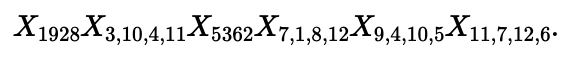

In [11]:
from processing import get_other_occurrance_table

get_other_occurrance_table([1,4,2,5,3,6,4,1,5,2,6,3])

[7, 6, 9, 8, 11, 10, 1, 0, 3, 2, 5, 4]

In [22]:
from utilities import format_for_pytorch_geo

format_for_pytorch_geo([1, -1, 1, 1, -1, 1], new_shape=(1,-1))

tensor([[ 1.],
        [-1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.]])

In [44]:
sym_types = set()

for knot_id, knot in knots.items():
    if "sym_type" in knot.keys():
        sym_types.add(knot["sym_type"])

In [45]:
sym_types

{'Chiral', 'Fully amphicheiral', 'Negative amphicheiral', 'Reversible'}

In [28]:
knot_id

'T(7,6)'

In [48]:
broken = []

for knot_id, knot in knots.items():
    if "sym_type" not in knot.keys():
        broken.append(knot_id)

broken

[]

In [53]:
from torch_geometric.data import Data
import torch

a = Data(x=format_for_pytorch_geo([1,2,3], new_shape=(-1,1), new_type=torch.float))

In [54]:
a.clone()

Data(x=[1, 3])

In [55]:
a

Data(x=[1, 3])

In [59]:
format_for_pytorch_geo([1,2,3], new_shape=(1,-1), new_type=torch.float).shape

torch.Size([3, 1])

In [100]:
lmao[8]

5

In [1]:
from transformations import *

knot = graphs[0]
new_knot = mirror_knot(graphs[0])

/Users/midataur/Documents/github/knot-invariants/venv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'graphs' is not defined

In [148]:
knot.x

tensor([[-1.],
        [-1.],
        [-1.]])

In [149]:
new_knot.x

tensor([[1.],
        [1.],
        [1.]])

In [132]:
graphs[429]

Data(x=[8, 1], edge_index=[2, 16], edge_attr=[16, 1], knot_id='8_20')

## Transformation tests

In [1]:
import processing

raw_filename = "../datasets/raw_dir/katlas.rdf"

knots = processing.get_knots(raw_filename)
graphs = processing.get_graphs(knots)

trefoil = graphs[0]

/Users/midataur/Documents/github/knot-invariants/venv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Constructing graphs...: 100%|██████████| 838/838 [00:00<00:00, 3835.29it/s]


In [2]:
from utilities import *
from transformations import *
import torch

post_twist = twist(trefoil, 0, 1)

In [ ]:
def get_face(graph, pos, side):
    """
        Gets the face an edge belongs to.
        Set side = +1 for left face, -1 for right.
    """
    cur = pos

    face = set()

    while True:

def detect_faces(graph):
    """Finds all the faces in a graph"""

    faces = set()

    for pos, edge in enumerate(graph.edge_index.t()):
        # get left face
        faces.add(get_face(graph, pos, side=1))

In [5]:
len(graphs)

2058